# Prediksi LST 2024 — Random Forest dan SVR

**NDVI dan NDBI 2024 tetap digunakan sebagai variabel independen.**
LST 2024 adalah target; LST 2009–2021 adalah lag; NDVI/NDBI 2009–2024 adalah prediktor.
Ini adalah prediksi LST bersyarat pada indeks 2024 yang telah tersedia, bukan ramalan
sebelum indeks 2024 diketahui. Evaluasi di sini adalah holdout antargrid, bukan uji
generalisasi ke tahun mendatang. Label klaster adalah input penelitian yang sudah ada;
pastikan pembentukannya tidak menggunakan target LST 2024. Split acak spasial dapat
memberikan skor optimistis untuk lokasi baru yang jauh dari grid latih.

| Model | Variabel independen | Jumlah fitur |
|---|---|---:|
| M1 | LST 2009, 2012, 2015, 2018, 2021 | 5 |
| M2 | Sama dengan M1, model terpisah per klaster | 5 |
| M3 | Lag LST + NDVI/NDBI 2009, 2012, 2015, 2018, 2021, **2024** | 17 |
| M4 | Sama dengan M3, model terpisah per klaster | 17 |

## Urutan penggunaan
1. Jalankan notebook lokal dari root proyek atau folder `sintaks`.
2. Input dibaca dari `C:/Users/Solideo G. Bangun/uhi-dashboard/data`:
   - `NDVI_NDBI_Jakarta_v2/NDVI_NDBI_Grid1km_Jakarta_Landsat_OLIref_v2.geojson`
   - `cluster_spatial_k4.geojson`
   - `LSTPuncakKemarau.geojson`
3. Audit cakupan dalam subfolder indeks ditampilkan sebelum menyiapkan data model.
   Grid tanpa klaster/LST dicatat dan dikeluarkan; kualitas data tidak dilonggarkan.
4. Jika memakai Colab, salin folder `data` ke Drive dan sesuaikan `COLAB_DATA_DIR`.
   Colab tidak dapat mengakses path Windows lokal secara langsung.

Jika suatu periode tidak mempunyai grid valid, notebook tetap membaca dan
mengekspor audit, lalu berhenti dengan keterangan periode tersebut. Pelatihan
baru bisa dilanjutkan setelah data sumbernya tersedia/lolos kualitas.

Indeks Landsat 7 disesuaikan ke referensi OLI menggunakan koefisien reflektansi RMA
Roy et al. (2016), Tabel 2. Transfer koefisien ini **belum divalidasi lokal di Jakarta**
dan bukan produk HLS. Kolom `NDVI_raw`/`NDBI_raw` disimpan untuk uji sensitivitas.
StandardScaler SVR bekerja per kolom tahun hanya pada data latih; tidak menggantikan
penyesuaian sensor. Tidak dilakukan z-score per tahun pada data deskriptif.

Rujukan: [Roy et al.](https://pmc.ncbi.nlm.nih.gov/articles/PMC6999663/),
[reduksi spasial Earth Engine](https://developers.google.com/earth-engine/apidocs/ee-image-reduceregions).

## Revisi untuk keterbatasan citra 2009
Ekspor awal hanya mempunyai dua tanggal citra 2009. Dengan syarat setiap piksel
valid pada dua tanggal, seluruh grid gagal ambang cakupan 80% dan indeksnya null.
Skrip `obs_support_v3` kini memakai minimal satu pengamatan valid per piksel untuk
semua periode; cakupan 80% tetap wajib. Ini kompromi dukungan temporal, bukan
jaminan kualitas komposit setara dengan banyak pengamatan. Audit menyimpan luas
dengan >=1 dan >=2 pengamatan serta luas yang hanya memiliki satu pengamatan.

Jalankan ulang skrip Earth Engine, selesaikan kedua Tasks, lalu ganti GeoJSON dan
audit CSV lama di `data/NDVI_NDBI_Jakarta_v2`. Restart Kernel dan Run All setelah
mengganti file. Notebook tidak dapat mengembalikan indeks yang sudah null.


In [7]:
# Di Colab, instal seluruh dependensi analisis termasuk SHAP.
import sys
import subprocess
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
                           'geopandas', 'scikit-learn', 'matplotlib', 'shap', 'joblib'])
    drive.mount('/content/drive')


## 1. Konfigurasi input, kualitas, dan model


In [8]:
from pathlib import Path
import json
import hashlib
import math
import warnings
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

# Folder data proyek; bekerja dari root proyek maupun dari folder sintaks.
# Di Colab, salin folder data ke Drive dan sesuaikan COLAB_DATA_DIR.
LOCAL_DATA_DIR = Path(r'C:/Users/Solideo G. Bangun/uhi-dashboard/data')
COLAB_DATA_DIR = Path('/content/drive/MyDrive/uhi-dashboard/data')
# Opsional: isi Path(...) untuk lokasi lain. Juga dipakai pengujian terisolasi.
DATA_DIR_OVERRIDE = globals().get('DATA_DIR_OVERRIDE', None)
if DATA_DIR_OVERRIDE is not None:
    BASE_DIR = Path(DATA_DIR_OVERRIDE)
elif IN_COLAB:
    BASE_DIR = COLAB_DATA_DIR
else:
    candidates = [LOCAL_DATA_DIR, Path.cwd() / 'data', Path.cwd().parent / 'data']
    BASE_DIR = next((folder for folder in candidates
                     if (folder / 'LSTPuncakKemarau.geojson').is_file()), LOCAL_DATA_DIR)
PATH_NDVI_NDBI = BASE_DIR / 'NDVI_NDBI_Jakarta_v2/NDVI_NDBI_Grid1km_Jakarta_Landsat_OLIref_v2.geojson'
PATH_AUDIT_CAKUPAN = BASE_DIR / 'NDVI_NDBI_Jakarta_v2/audit_cakupan_landsat_v2.csv'
PATH_CLUSTER = BASE_DIR / 'cluster_spatial_k4.geojson'
PATH_LST = BASE_DIR / 'LSTPuncakKemarau.geojson'
OUTPUT_DIR = BASE_DIR / 'output/regression_landsat_v2'

LAG_YEARS = [2009, 2012, 2015, 2018, 2021]
TARGET_YEAR = 2024
INDEX_YEARS = LAG_YEARS + [TARGET_YEAR]  # 2024 tetap dipakai, sesuai rancangan pengguna
TARGET_COL = f'lst_{TARGET_YEAR}'
CLUSTER_RAW, CLUSTER_COL = 'k-means_cluster', 'kmeans_cluster'
MIN_VALID_FRACTION = 0.80
MIN_OBSERVATIONS = 1  # >=80% area grid tetap wajib; dukungan >=2 dilaporkan
TEST_SIZE, CV_FOLDS, SEED = 0.2, 5, 42
RF_PARAMS = dict(n_estimators=300, max_features='sqrt', random_state=SEED, n_jobs=-1)
SVR_PARAMS = dict(kernel='rbf', C=10, gamma='scale', epsilon=0.1)
RUN_SENSITIVITY = True  # model raw vs adjusted pada grid, split, dan fold yang identik
RUN_SHAP = True
SHAP_BACKGROUND_SIZE = 40  # subsampel data latih, bukan data uji

lst_cols = [f'lst_{y}' for y in LAG_YEARS]
ndvi_cols = [f'ndvi{y}' for y in INDEX_YEARS]
ndbi_cols = [f'ndbi{y}' for y in INDEX_YEARS]
MODEL_CONFIGS = {
    'M1_LagLST': dict(label='M1: Lag LST saja', features=lst_cols, per_cluster=False),
    'M2_LagLST_byCluster': dict(label='M2: Lag LST (per Cluster)', features=lst_cols, per_cluster=True),
    'M3_LagAll': dict(label='M3: Lag LST + NDVI + NDBI', features=lst_cols + ndvi_cols + ndbi_cols, per_cluster=False),
    'M4_LagAll_byCluster': dict(label='M4: Lag LST + NDVI + NDBI (per Cluster)', features=lst_cols + ndvi_cols + ndbi_cols, per_cluster=True),
}
assert all(TARGET_COL not in c['features'] for c in MODEL_CONFIGS.values())
assert 'ndvi2024' in MODEL_CONFIGS['M3_LagAll']['features']
assert 'ndbi2024' in MODEL_CONFIGS['M4_LagAll_byCluster']['features']
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Indeks:', PATH_NDVI_NDBI)
print('Output:', OUTPUT_DIR)


Indeks: C:\Users\Solideo G. Bangun\uhi-dashboard\data\NDVI_NDBI_Jakarta_v2\NDVI_NDBI_Grid1km_Jakarta_Landsat_OLIref_v2.geojson
Output: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_landsat_v2


## 2. Pemeriksaan sumber dan panel grid × periode

Input indeks harus memiliki metadata versi, cakupan valid, jumlah pengamatan,
metode penyesuaian, dan nilai pembanding raw. `scene_count_aoi` adalah jumlah scene
untuk seluruh wilayah; `n_valid_pixels` adalah jumlah piksel valid per grid.
Grid dengan kualitas rendah tidak diinterpolasi ke/dari tahun lain.
Analisis utama memakai complete cases yang sama pada semua model dan kedua skenario.
Daftar grid yang keluar disimpan agar perubahan cakupan bisa diperiksa.


In [9]:
def normalize_ids(frame):
    frame = frame.copy()
    if 'grid_id' not in frame or frame['grid_id'].isna().any():
        raise ValueError('grid_id hilang atau kosong.')
    frame['grid_id'] = frame['grid_id'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
    if frame['grid_id'].eq('').any():
        raise ValueError('grid_id kosong.')
    return frame


def require_columns(frame, columns, source):
    missing = sorted(set(columns) - set(frame.columns))
    if missing:
        raise ValueError(f'{source}: kolom wajib hilang: {missing}')


def load_indices(path):
    if not Path(path).exists():
        raise FileNotFoundError(f'Ekspor baru belum tersedia: {path}. Jalankan ndvi_ndbi_jkt.js dan kedua Tasks di Earth Engine dahulu.')
    panel = normalize_ids(gpd.read_file(path))
    required = ['year', 'sensor', 'NDVI', 'NDBI', 'NDVI_raw', 'NDBI_raw',
                'valid_fraction', 'n_valid_pixels', 'obs_mean', 'scene_count_aoi',
                'unique_days_aoi', 'quality_ok', 'min_observations', 'min_valid_fraction',
                'analysis_scale_m', 'analysis_crs', 'schema_version', 'harmonization',
                'local_validation', 'start_date', 'end_date_exclusive']
    require_columns(panel, required, 'Ekspor indeks v2')
    if panel.empty or not panel['schema_version'].eq('landsat_oli_v2').all():
        raise ValueError('Gunakan ekspor landsat_oli_v2; data lama tidak disamakan dengan data revisi.')
    panel['year'] = pd.to_numeric(panel['year'], errors='raise').astype(int)
    if set(panel['year']) != set(INDEX_YEARS):
        raise ValueError(f'Periode harus tepat {INDEX_YEARS}.')
    if panel.duplicated(['grid_id', 'year']).any():
        raise ValueError('Duplikat grid_id/tahun tidak boleh diagregasi diam-diam.')
    reference_ids = set(panel.loc[panel['year'].eq(INDEX_YEARS[0]), 'grid_id'])
    for year, part in panel.groupby('year'):
        if set(part['grid_id']) != reference_ids:
            raise ValueError(f'Daftar grid tidak konsisten pada {year}; ekspor juga grid yang null.')
        expected_sensor = 'landsat7' if year < 2013 else 'landsat8'
        method = 'Roy2016_Table2_SR_RMA_ETM_to_OLI' if year < 2013 else 'OLI_reference'
        if not part['sensor'].eq(expected_sensor).all() or not part['harmonization'].eq(method).all():
            raise ValueError(f'Sensor/metode penyesuaian tidak sesuai pada {year}.')
        if not part['start_date'].eq(f'{year}-06-01').all() or not part['end_date_exclusive'].eq(f'{year}-10-01').all():
            raise ValueError('Jendela musim tidak konsisten: gunakan 1 Juni sampai sebelum 1 Oktober.')
    numeric = ['NDVI', 'NDBI', 'NDVI_raw', 'NDBI_raw', 'valid_fraction', 'n_valid_pixels',
               'obs_mean', 'scene_count_aoi', 'unique_days_aoi', 'quality_ok',
               'min_observations', 'min_valid_fraction', 'analysis_scale_m']
    for col in numeric:
        panel[col] = pd.to_numeric(panel[col], errors='raise')
    if not panel['analysis_scale_m'].eq(30).all() or not panel['analysis_crs'].eq('EPSG:32748').all():
        raise ValueError('Skala/proyeksi analisis berbeda dari grid bersama 30 m UTM 48S.')
    if not panel['valid_fraction'].between(0, 1.000001).all():
        raise ValueError('valid_fraction harus berada dalam [0, 1].')
    if not panel['quality_ok'].isin([0, 1]).all():
        raise ValueError('quality_ok harus 0 atau 1.')
    if panel['min_observations'].nunique(dropna=False) != 1:
        raise ValueError('Ambang pengamatan berbeda antarbaris/periode; ekspor ulang semua periode dengan konfigurasi sama.')
    if not panel['min_observations'].ge(MIN_OBSERVATIONS).all():
        raise ValueError('Ambang jumlah observasi saat ekstraksi terlalu rendah; ekspor ulang.')
    if panel[['scene_count_aoi', 'unique_days_aoi', 'n_valid_pixels', 'obs_mean']].lt(0).any().any():
        raise ValueError('Jumlah scene/piksel/observasi tidak boleh negatif.')
    for col in ['NDVI', 'NDBI', 'NDVI_raw', 'NDBI_raw']:
        values = panel[col].dropna()
        if not values.between(-1, 1).all():
            raise ValueError(f'{col} mengandung nilai di luar [-1,1].')
    panel['usable'] = (panel['quality_ok'].eq(1)
                       & panel['valid_fraction'].ge(MIN_VALID_FRACTION)
                       & panel['n_valid_pixels'].gt(0)
                       & panel['unique_days_aoi'].ge(MIN_OBSERVATIONS)
                       & panel[['NDVI', 'NDBI', 'NDVI_raw', 'NDBI_raw']].notna().all(axis=1))
    # Gagal QA tetap tercatat, tetapi tidak boleh masuk fitur atau statistik indeks.
    panel.loc[~panel['usable'], ['NDVI', 'NDBI', 'NDVI_raw', 'NDBI_raw']] = np.nan
    if panel.geometry.isna().any() or panel.geometry.is_empty.any() or panel.crs is None:
        raise ValueError('Geometri/CRS grid tidak valid.')
    for _, part in panel.groupby('grid_id', sort=False):
        first = part.geometry.iloc[0]
        if not all(first.equals(g) for g in part.geometry):
            raise ValueError('Geometri grid berubah antarperiode.')
    return panel.sort_values(['grid_id', 'year']).reset_index(drop=True)


def load_lst(path):
    path = Path(path)
    if path.suffix.lower() == '.csv':
        data = normalize_ids(pd.read_csv(path, dtype={'grid_id': str}))
        if TARGET_COL not in data and f'{TARGET_COL}_EXCLUDED' in data:
            data = data.rename(columns={f'{TARGET_COL}_EXCLUDED': TARGET_COL})
    else:
        source = normalize_ids(gpd.read_file(path))
        require_columns(source, ['period', 'mean'], 'LST format panjang')
        source['year'] = pd.to_numeric(source['period'].astype(str).str.extract(r'(\d{4})')[0], errors='raise').astype(int)
        source = source[source['year'].isin(INDEX_YEARS)]
        if source.duplicated(['grid_id', 'year']).any():
            raise ValueError('Duplikat grid/tahun dalam LST.')
        data = source.pivot(index='grid_id', columns='year', values='mean')
        data.columns = [f'lst_{int(y)}' for y in data.columns]
        data = data.reset_index()
    require_columns(data, ['grid_id', *lst_cols, TARGET_COL], 'LST')
    if data['grid_id'].duplicated().any():
        raise ValueError('Duplikat grid pada LST.')
    data = data[['grid_id', *lst_cols, TARGET_COL]].copy()
    for col in lst_cols + [TARGET_COL]:
        data[col] = pd.to_numeric(data[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
    return data


def prepare_data(panel, cluster_path, lst_path):
    clusters = normalize_ids(gpd.read_file(cluster_path))
    require_columns(clusters, [CLUSTER_RAW], 'Klaster')
    if clusters['grid_id'].duplicated().any():
        raise ValueError('Duplikat grid pada klaster.')
    clusters = clusters[['grid_id', CLUSTER_RAW]].rename(columns={CLUSTER_RAW: CLUSTER_COL})
    clusters[CLUSTER_COL] = pd.to_numeric(clusters[CLUSTER_COL], errors='raise')
    lst = load_lst(lst_path)
    spatial = panel[['grid_id', 'geometry']].drop_duplicates('grid_id').copy()
    index_ids = set(spatial['grid_id'])
    # Data klaster dapat merupakan subset (grid tanpa LST tidak diklasterkan).
    # Pertahankan semua grid indeks dalam audit; missing cluster/LST akan dikeluarkan.
    differences = {
        'indeks_tanpa_klaster': sorted(index_ids - set(clusters['grid_id'])),
        'klaster_tanpa_indeks': sorted(set(clusters['grid_id']) - index_ids),
        'indeks_tanpa_lst': sorted(index_ids - set(lst['grid_id'])),
        'lst_tanpa_indeks': sorted(set(lst['grid_id']) - index_ids),
    }
    (OUTPUT_DIR / 'grid_id_mismatch.json').write_text(json.dumps(differences, indent=2), encoding='utf-8')
    if differences['klaster_tanpa_indeks'] or differences['lst_tanpa_indeks']:
        raise ValueError('LST/klaster memuat grid di luar grid indeks. Periksa grid_id_mismatch.json.')
    wide = pd.DataFrame(index=sorted(index_ids))
    wide.index.name = 'grid_id'
    for variable, prefix in [('NDVI', 'ndvi'), ('NDBI', 'ndbi'), ('NDVI_raw', 'ndvi_raw'), ('NDBI_raw', 'ndbi_raw')]:
        pivot = panel.pivot(index='grid_id', columns='year', values=variable)
        for year in INDEX_YEARS:
            wide[f'{prefix}{year}'] = pivot[year]
    merged = wide.reset_index().merge(clusters, on='grid_id', how='left', validate='one_to_one')
    merged = merged.merge(lst, on='grid_id', how='left', validate='one_to_one')
    raw_cols = [f'{v}_raw{y}' for v in ['ndvi', 'ndbi'] for y in INDEX_YEARS]
    required = lst_cols + ndvi_cols + ndbi_cols + raw_cols + [TARGET_COL, CLUSTER_COL]
    missing = merged[required].isna()
    audit = merged[['grid_id']].copy()
    audit['included'] = ~missing.any(axis=1)
    audit['missing_columns'] = missing.apply(lambda row: ','.join(row.index[row]), axis=1)
    audit.to_csv(OUTPUT_DIR / 'audit_grid_inclusion.csv', index=False)
    result = merged.loc[audit['included']].sort_values('grid_id').reset_index(drop=True)
    if result.empty:
        empty_years = [year for year in INDEX_YEARS
                       if not panel.loc[panel['year'].eq(year), 'usable'].any()]
        detail = f' Tidak ada grid indeks yang lolos pada periode {empty_years}.' if empty_years else ''
        raise ValueError('Tidak ada complete case untuk seluruh periode.' + detail
                         + ' Lihat audit_kualitas_periode.csv dan audit_grid_inclusion.csv.'
                         + ' Jalankan ulang ndvi_ndbi_jkt.js revisi obs_support_v3 (minObservations=1, cakupan tetap 80%).'
                         + ' Selesaikan kedua Tasks, ganti GeoJSON dan audit CSV dalam data/NDVI_NDBI_Jakarta_v2,'
                         + ' lalu Restart Kernel dan Run All. Mengubah ambang di notebook tidak memulihkan nilai null.')
    if not np.allclose(result[CLUSTER_COL], np.round(result[CLUSTER_COL])):
        raise ValueError('Label klaster harus bilangan bulat.')
    result[CLUSTER_COL] = result[CLUSTER_COL].astype(int)
    print(f'{len(result)} dari {len(merged)} grid masuk analisis; {len(merged)-len(result)} keluar.')
    return result, spatial, audit


In [10]:
panel = load_indices(PATH_NDVI_NDBI)
quality = panel.groupby(['year', 'sensor'], as_index=False).agg(
    n_grids=('grid_id', 'size'), n_usable=('usable', 'sum'),
    valid_fraction_mean=('valid_fraction', 'mean'), valid_fraction_min=('valid_fraction', 'min'),
    scene_count_aoi=('scene_count_aoi', 'max'), unique_days_aoi=('unique_days_aoi', 'max'))
quality.to_csv(OUTPUT_DIR / 'audit_kualitas_periode.csv', index=False)
panel.drop(columns='geometry').to_csv(OUTPUT_DIR / 'panel_indeks_qa.csv', index=False)
display(quality)
print('Minimum pengamatan saat ekstraksi:', sorted(panel['min_observations'].unique()))
if {'valid_fraction_ge1', 'valid_fraction_ge2', 'single_obs_fraction'}.issubset(panel.columns):
    observation_support = panel.groupby('year', as_index=False).agg(
        coverage_ge1=('valid_fraction_ge1', 'mean'),
        coverage_ge2=('valid_fraction_ge2', 'mean'),
        area_with_only_one_observation=('single_obs_fraction', 'mean'))
    observation_support.to_csv(OUTPUT_DIR / 'audit_dukungan_observasi.csv', index=False)
    display(observation_support)
else:
    print('Ekspor lama: rincian dukungan 1 vs 2 pengamatan belum tersedia. Ekspor ulang skrip revisi obs_support_v3.')
if PATH_AUDIT_CAKUPAN.exists():
    print('Audit ekstraksi Earth Engine:')
    display(pd.read_csv(PATH_AUDIT_CAKUPAN).drop(columns=['.geo'], errors='ignore'))
df, grid_geometry, inclusion_audit = prepare_data(panel, PATH_CLUSTER, PATH_LST)
df.to_csv(OUTPUT_DIR / 'analysis_complete_cases.csv', index=False)
display(df.head())
print('Status validasi lokal:', panel['local_validation'].unique().tolist())
print('Tidak ada interpolasi temporal; NDVI/NDBI 2024 termasuk dalam pemeriksaan kelengkapan.')


,year,sensor,n_grids,n_usable,valid_fraction_mean,valid_fraction_min,scene_count_aoi,unique_days_aoi
0,2009,landsat7,644,636,0.981175,0.694825,2,2
1,2012,landsat7,644,643,0.993755,0.791558,4,4
2,2015,landsat8,644,644,0.993739,0.955694,12,7
3,2018,landsat8,644,644,0.993694,0.955694,14,8
4,2021,landsat8,644,643,0.991732,0.702166,8,4
5,2024,landsat8,644,644,0.993730,0.955694,10,6


Minimum pengamatan saat ekstraksi: [1]


,year,coverage_ge1,coverage_ge2,area_with_only_one_observation
0,2009,0.983081,0.593839,0.389241
1,2012,0.995682,0.880876,0.114806
2,2015,0.995657,0.995646,0.000011
3,2018,0.995612,0.991731,0.003881
4,2021,0.993646,0.876126,0.117520
5,2024,0.995649,0.995636,0.000013


Audit ekstraksi Earth Engine:


,system:index,mean_single_obs_fraction,mean_valid_fraction,mean_valid_fraction_ge1,mean_valid_fraction_ge2,min_observations,min_valid_fraction,min_valid_fraction_observed,n_grids,n_grids_fail,n_grids_pass,n_grids_pass_ge2,scene_count_catalog,scene_count_filtered,sensor,unique_days,year
0,0,0.389241,0.981175,0.983081,0.593839,1,0.8,0.694825,644,8,636,3,2,2,landsat7,2,2009
1,1,0.114806,0.993755,0.995682,0.880876,1,0.8,0.791558,644,1,643,541,5,4,landsat7,4,2012
2,2,0.000011,0.993739,0.995657,0.995646,1,0.8,0.955694,644,0,644,644,14,12,landsat8,7,2015
3,3,0.003881,0.993694,0.995612,0.991731,1,0.8,0.955694,644,0,644,639,16,14,landsat8,8,2018
4,4,0.117520,0.991732,0.993646,0.876126,1,0.8,0.702166,644,1,643,506,14,8,landsat8,4,2021
5,5,0.000013,0.993730,0.995649,0.995636,1,0.8,0.955694,644,0,644,644,16,10,landsat8,6,2024


629 dari 644 grid masuk analisis; 15 keluar.


,grid_id,ndvi2009,ndvi2012,ndvi2015,ndvi2018,ndvi2021,ndvi2024,ndbi2009,ndbi2012,ndbi2015,...,ndbi_raw2018,ndbi_raw2021,ndbi_raw2024,kmeans_cluster,lst_2009,lst_2012,lst_2015,lst_2018,lst_2021,lst_2024
0,92955000708,0.420967,0.416925,0.459297,0.430107,0.433780,0.419154,-0.078734,-0.067698,-0.079070,...,-0.063905,-0.075936,-0.057359,4,36.668588,36.146513,38.228577,37.834997,36.914275,34.535053
1,92955000709,0.511669,0.457024,0.516814,0.512818,0.552884,0.552280,-0.145783,-0.117413,-0.114140,...,-0.125368,-0.171921,-0.156707,3,35.868047,35.298629,37.254754,37.319911,35.722285,33.313516
2,92965000698,0.573212,0.561908,0.560588,0.590014,0.645011,0.649197,-0.102632,-0.101362,-0.082571,...,-0.125960,-0.167659,-0.190449,4,36.079414,34.914972,37.529866,36.908929,35.779453,33.461384
3,92965000699,0.446398,0.415784,0.455727,0.439894,0.430984,0.431598,-0.086369,-0.063217,-0.068128,...,-0.051178,-0.045887,-0.050008,4,36.030412,34.949330,37.627289,36.884331,35.703353,33.510459
4,92965000707,0.384022,0.344795,0.364897,0.354014,0.330146,0.311283,-0.033260,-0.011591,-0.003660,...,0.022806,0.028610,0.050143,4,37.692706,37.068831,38.647737,38.749485,38.086196,35.517092


Status validasi lokal: ['not_performed']
Tidak ada interpolasi temporal; NDVI/NDBI 2024 termasuk dalam pemeriksaan kelengkapan.


## 3. Statistik deskriptif dan sensitivitas penyesuaian sensor
Grafik memakai grid complete case yang sama di semua periode. Selisih adjusted−raw
mengukur efek transformasi pada data ini, bukan bukti akurasi koreksi antarsensor.


,year,variable,n,mean,std,raw_mean,mean_adjustment,rms_adjustment
0,2009,NDVI,629,0.26355,0.09918,0.24812,0.01543,0.01545
1,2009,NDBI,629,-0.00964,0.07016,-0.01156,0.00192,0.00281
2,2012,NDVI,629,0.25016,0.09123,0.23483,0.01533,0.01534
3,2012,NDBI,629,-0.00482,0.06607,-0.00686,0.00204,0.00270
4,2015,NDVI,629,0.30182,0.09248,0.30182,0.00000,0.00000
5,2015,NDBI,629,-0.00459,0.06249,-0.00459,0.00000,0.00000
6,2018,NDVI,629,0.30807,0.09134,0.30807,0.00000,0.00000
7,2018,NDBI,629,-0.00253,0.06592,-0.00253,0.00000,0.00000
8,2021,NDVI,629,0.32503,0.09761,0.32503,0.00000,0.00000
9,2021,NDBI,629,-0.01298,0.07601,-0.01298,0.00000,0.00000


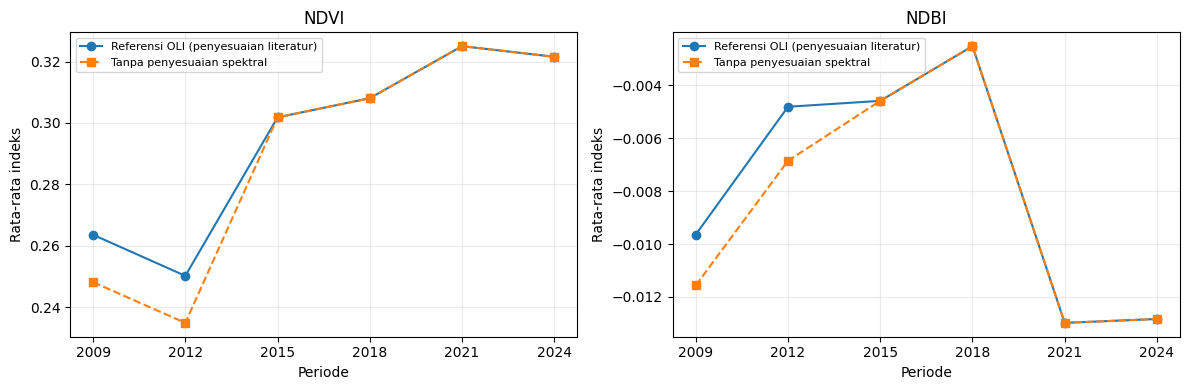

In [11]:
balanced = panel[panel['grid_id'].isin(df['grid_id'])].copy()
rows = []
for year, part in balanced.groupby('year'):
    for variable in ['NDVI', 'NDBI']:
        delta = part[variable] - part[variable + '_raw']
        rows.append(dict(year=year, variable=variable, n=len(part),
                         mean=part[variable].mean(), std=part[variable].std(),
                         raw_mean=part[variable+'_raw'].mean(), mean_adjustment=delta.mean(),
                         rms_adjustment=np.sqrt(np.mean(delta ** 2))))
descriptive = pd.DataFrame(rows)
descriptive.to_csv(OUTPUT_DIR / 'statistik_indeks_periode.csv', index=False)
display(descriptive.round(5))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, variable in zip(axes, ['NDVI', 'NDBI']):
    part = descriptive[descriptive['variable'].eq(variable)]
    ax.plot(part['year'], part['mean'], 'o-', label='Referensi OLI (penyesuaian literatur)')
    ax.plot(part['year'], part['raw_mean'], 's--', label='Tanpa penyesuaian spektral')
    ax.set(title=variable, xlabel='Periode', ylabel='Rata-rata indeks')
    ax.set_xticks(INDEX_YEARS)
    ax.legend(fontsize=8)
    ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'tren_indeks_raw_adjusted.png', dpi=160)
plt.show()
plt.close(fig)


## 4. Split dan validasi model

Semua model memakai grid latih/uji dan fold CV yang sama. CV hanya memakai data
latih; M2/M4 benar-benar melatih model per klaster pada setiap fold. SVR melakukan
standardisasi di dalam pipeline sehingga statistik data uji tidak dipakai.
Model pilihan ditentukan dari CV data latih, bukan skor holdout.
RMSE/MAE (°C) menjadi ukuran kesalahan utama. MAPE pada Celsius sensitif terhadap
titik nol skala, sedangkan adjusted R² berbasis jumlah fitur hanya ukuran tambahan
dan bukan estimasi derajat kebebasan efektif RF/SVR.


In [12]:
def make_model(algorithm):
    if algorithm == 'RF':
        return RandomForestRegressor(**RF_PARAMS)
    if algorithm == 'SVR':
        return Pipeline([('scaler', StandardScaler()), ('svr', SVR(**SVR_PARAMS))])
    raise ValueError(f'Algoritma tidak dikenal: {algorithm}')


def split_data(frame):
    labels = frame[CLUSTER_COL].to_numpy()
    counts = pd.Series(labels).value_counts()
    if counts.min() < 5:
        raise ValueError('Terlalu sedikit complete case di suatu klaster untuk holdout dan CV; periksa audit kualitas.')
    train, test = train_test_split(np.arange(len(frame)), test_size=TEST_SIZE,
                                   random_state=SEED, stratify=labels)
    train, test = np.sort(train), np.sort(test)
    if pd.Series(labels[test]).value_counts().reindex(counts.index, fill_value=0).min() < 2:
        raise ValueError('Setiap klaster perlu minimal dua grid uji untuk R2; sesuaikan split/data.')
    n_folds = min(CV_FOLDS, int(pd.Series(labels[train]).value_counts().min()))
    if n_folds < 2:
        raise ValueError('Data latih tidak cukup untuk cross-validation.')
    splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    folds = [(train[a], train[b]) for a, b in splitter.split(train, labels[train])]
    return train, test, folds


def fit_partition(frame, indices, config, algorithm):
    feats = config['features']
    labels = frame[CLUSTER_COL].to_numpy()
    keys = sorted(np.unique(labels[indices])) if config['per_cluster'] else ['global']
    models = {}
    for key in keys:
        members = indices[labels[indices] == key] if key != 'global' else indices
        model = make_model(algorithm)
        model.fit(frame.iloc[members][feats].to_numpy(), frame.iloc[members][TARGET_COL].to_numpy())
        models[key] = model
    return models


def predict_partition(frame, indices, config, models):
    labels = frame.iloc[indices][CLUSTER_COL].to_numpy()
    features = frame.iloc[indices][config['features']].to_numpy()
    prediction = np.full(len(indices), np.nan)
    keys = sorted(np.unique(labels)) if config['per_cluster'] else ['global']
    for key in keys:
        if key not in models:
            raise ValueError(f'Klaster {key} tidak memiliki model latih.')
        mask = labels == key if key != 'global' else np.ones(len(indices), dtype=bool)
        prediction[mask] = models[key].predict(features[mask])
    if not np.isfinite(prediction).all():
        raise ValueError('Ada prediksi kosong/tidak finite.')
    return prediction


def metrics(y, prediction, n_features, prefix=''):
    y, prediction = np.asarray(y), np.asarray(prediction)
    score = r2_score(y, prediction) if len(y) >= 2 else np.nan
    adj = 1 - (1-score)*(len(y)-1)/(len(y)-n_features-1) if len(y) > n_features+1 else np.nan
    nonzero = np.abs(y) > 1e-10
    values = dict(R2=score, Adj_R2=adj, RMSE=np.sqrt(mean_squared_error(y, prediction)),
                  MAE=mean_absolute_error(y, prediction),
                  MAPE=np.mean(np.abs((y[nonzero]-prediction[nonzero])/y[nonzero]))*100 if nonzero.any() else np.nan)
    return {prefix+k: float(v) for k, v in values.items()}


def evaluate_configuration(frame, config, algorithm, train, test, folds):
    cv_r2, cv_rmse = [], []
    for fold_train, fold_validation in folds:
        if np.intersect1d(fold_train, test).size or np.intersect1d(fold_validation, test).size:
            raise ValueError('Holdout masuk ke CV.')
        fold_models = fit_partition(frame, fold_train, config, algorithm)
        prediction = predict_partition(frame, fold_validation, config, fold_models)
        scores = metrics(frame.iloc[fold_validation][TARGET_COL], prediction, len(config['features']))
        cv_r2.append(scores['R2'])
        cv_rmse.append(scores['RMSE'])
    models = fit_partition(frame, train, config, algorithm)
    train_prediction = predict_partition(frame, train, config, models)
    test_prediction = predict_partition(frame, test, config, models)
    scores = metrics(frame.iloc[train][TARGET_COL], train_prediction, len(config['features']), 'Train_')
    scores.update(metrics(frame.iloc[test][TARGET_COL], test_prediction, len(config['features']), 'Test_'))
    scores.update(CV_R2_Mean=float(np.mean(cv_r2)), CV_R2_Std=float(np.std(cv_r2)),
                  CV_RMSE_Mean=float(np.mean(cv_rmse)), CV_Folds=len(folds))
    return dict(models=models, train_indices=train.copy(), test_indices=test.copy(),
                train_prediction=train_prediction, test_prediction=test_prediction,
                features=list(config['features']), metrics=scores)


In [13]:
train_indices, test_indices, cv_folds = split_data(df)
split_audit = df[['grid_id', CLUSTER_COL]].copy()
split_audit['split'] = 'train'
split_audit.loc[test_indices, 'split'] = 'test'
split_audit['cv_validation_fold'] = pd.Series(pd.NA, index=df.index, dtype='Int64')
for fold, (_, validation) in enumerate(cv_folds, start=1):
    split_audit.loc[validation, 'cv_validation_fold'] = fold
split_audit.to_csv(OUTPUT_DIR / 'split_membership.csv', index=False)
display(pd.crosstab(split_audit[CLUSTER_COL], split_audit['split']))

all_results, summary_rows, cluster_rows, scaler_rows = {}, [], [], []
for config_key, config in MODEL_CONFIGS.items():
    for algorithm in ['RF', 'SVR']:
        print('Melatih:', config_key, algorithm, flush=True)
        result = evaluate_configuration(df, config, algorithm, train_indices, test_indices, cv_folds)
        all_results[(config_key, algorithm)] = result
        summary_rows.append(dict(ConfigKey=config_key, Config=config['label'], Algorithm=algorithm,
                                 N_Features=len(config['features']),
                                 Split='Per Cluster' if config['per_cluster'] else 'Semua Grid',
                                 **result['metrics']))
        labels_test = df.iloc[test_indices][CLUSTER_COL].to_numpy()
        for cluster in sorted(df[CLUSTER_COL].unique()):
            mask = labels_test == cluster
            cluster_rows.append(dict(ConfigKey=config_key, Algorithm=algorithm, Cluster=int(cluster),
                                     n_test=int(mask.sum()), **metrics(df.iloc[test_indices][TARGET_COL].to_numpy()[mask],
                                     result['test_prediction'][mask], len(config['features']))))
        if algorithm == 'SVR':
            for key, model in result['models'].items():
                scaler = model.named_steps['scaler']
                for feature, mean, scale, variance in zip(config['features'], scaler.mean_, scaler.scale_, scaler.var_):
                    scaler_rows.append(dict(ConfigKey=config_key, Cluster=str(key), feature=feature,
                                            train_mean=float(mean), train_scale=float(scale), train_variance=float(variance)))
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(OUTPUT_DIR / 'summary_evaluation.csv', index=False)
pd.DataFrame(cluster_rows).to_csv(OUTPUT_DIR / 'evaluation_per_cluster.csv', index=False)
pd.DataFrame(scaler_rows).to_csv(OUTPUT_DIR / 'standardisasi_svr_data_latih.csv', index=False)
best_keys = {algorithm: df_summary[df_summary['Algorithm'].eq(algorithm)]
             .sort_values(['CV_RMSE_Mean', 'ConfigKey']).iloc[0]['ConfigKey'] for algorithm in ['RF', 'SVR']}
display(df_summary.round(4))
print('Model pilihan berdasarkan CV RMSE data latih:', best_keys)


split,test,train
kmeans_cluster,,
1,25,97
2,29,117
3,40,160
4,32,129


Melatih: M1_LagLST RF
Melatih: M1_LagLST SVR
Melatih: M2_LagLST_byCluster RF
Melatih: M2_LagLST_byCluster SVR
Melatih: M3_LagAll RF
Melatih: M3_LagAll SVR
Melatih: M4_LagAll_byCluster RF
Melatih: M4_LagAll_byCluster SVR


,ConfigKey,Config,Algorithm,N_Features,Split,Train_R2,Train_Adj_R2,Train_RMSE,Train_MAE,Train_MAPE,Test_R2,Test_Adj_R2,Test_RMSE,Test_MAE,Test_MAPE,CV_R2_Mean,CV_R2_Std,CV_RMSE_Mean,CV_Folds
0,M1_LagLST,M1: Lag LST saja,RF,5,Semua Grid,0.9911,0.9910,0.0810,0.0633,0.1816,0.9465,0.9443,0.2296,0.1840,0.5282,0.9309,0.0142,0.2207,5
1,M1_LagLST,M1: Lag LST saja,SVR,5,Semua Grid,0.9580,0.9576,0.1757,0.1369,0.3909,0.9461,0.9438,0.2305,0.1778,0.5114,0.9310,0.0199,0.2191,5
2,M2_LagLST_byCluster,M2: Lag LST (per Cluster),RF,5,Per Cluster,0.9909,0.9908,0.0820,0.0623,0.1790,0.9485,0.9464,0.2253,0.1708,0.4923,0.9227,0.0206,0.2314,5
3,M2_LagLST_byCluster,M2: Lag LST (per Cluster),SVR,5,Per Cluster,0.9749,0.9746,0.1359,0.1073,0.3061,0.9431,0.9407,0.2368,0.1668,0.4815,0.9211,0.0317,0.2313,5
4,M3_LagAll,M3: Lag LST + NDVI + NDBI,RF,17,Semua Grid,0.9912,0.9909,0.0805,0.0620,0.1780,0.9439,0.9351,0.2351,0.1852,0.5335,0.9304,0.0091,0.2235,5
5,M3_LagAll,M3: Lag LST + NDVI + NDBI,SVR,17,Semua Grid,0.9763,0.9755,0.1320,0.1076,0.3072,0.9552,0.9482,0.2101,0.1611,0.4641,0.9166,0.0237,0.2411,5
6,M4_LagAll_byCluster,M4: Lag LST + NDVI + NDBI (per Cluster),RF,17,Per Cluster,0.9907,0.9904,0.0828,0.0614,0.1765,0.9550,0.9479,0.2106,0.1565,0.4509,0.9228,0.0185,0.2333,5
7,M4_LagAll_byCluster,M4: Lag LST + NDVI + NDBI (per Cluster),SVR,17,Per Cluster,0.9867,0.9862,0.0990,0.0864,0.2471,0.9427,0.9337,0.2376,0.1771,0.5112,0.8900,0.0535,0.2735,5


Model pilihan berdasarkan CV RMSE data latih: {'RF': 'M1_LagLST', 'SVR': 'M1_LagLST'}


## 5. Uji sensitivitas raw versus penyesuaian literatur
Memakai piksel/grid, holdout, dan fold yang sama. Perubahan skor menunjukkan
sensitivitas model terhadap transformasi; tidak membuktikan validitas harmonisasi
lokal maupun hubungan sebab-akibat NDVI/NDBI dengan LST.


In [14]:
sensitivity_rows = []
if RUN_SENSITIVITY:
    raw_frame = df.copy()
    for variable in ['ndvi', 'ndbi']:
        for year in INDEX_YEARS:
            raw_frame[f'{variable}{year}'] = raw_frame[f'{variable}_raw{year}']
    for key, config in MODEL_CONFIGS.items():
        if key.startswith(('M1', 'M2')):
            continue  # model tanpa indeks identik pada kedua skenario
        for algorithm in ['RF', 'SVR']:
            print('Sensitivitas raw:', key, algorithm, flush=True)
            raw_result = evaluate_configuration(raw_frame, config, algorithm, train_indices, test_indices, cv_folds)
            adjusted = all_results[(key, algorithm)]['metrics']
            sensitivity_rows.append(dict(ConfigKey=key, Algorithm=algorithm,
                raw_Test_RMSE=raw_result['metrics']['Test_RMSE'], adjusted_Test_RMSE=adjusted['Test_RMSE'],
                raw_CV_RMSE=raw_result['metrics']['CV_RMSE_Mean'], adjusted_CV_RMSE=adjusted['CV_RMSE_Mean'],
                delta_Test_RMSE=adjusted['Test_RMSE']-raw_result['metrics']['Test_RMSE']))
    sensitivity = pd.DataFrame(sensitivity_rows)
    sensitivity.to_csv(OUTPUT_DIR / 'sensitivity_raw_vs_adjusted.csv', index=False)
    display(sensitivity.round(5))


Sensitivitas raw: M3_LagAll RF
Sensitivitas raw: M3_LagAll SVR
Sensitivitas raw: M4_LagAll_byCluster RF
Sensitivitas raw: M4_LagAll_byCluster SVR


,ConfigKey,Algorithm,raw_Test_RMSE,adjusted_Test_RMSE,raw_CV_RMSE,adjusted_CV_RMSE,delta_Test_RMSE
0,M3_LagAll,RF,0.23476,0.23509,0.22336,0.22345,0.00032
1,M3_LagAll,SVR,0.20981,0.21006,0.24090,0.24109,0.00025
2,M4_LagAll_byCluster,RF,0.21071,0.21062,0.23325,0.23327,-0.00009
3,M4_LagAll_byCluster,SVR,0.23732,0.23761,0.27336,0.27350,0.00028


## 6. Ekspor prediksi, model, dan provenance


In [15]:
predictions = df.iloc[test_indices][['grid_id', TARGET_COL, CLUSTER_COL]].copy().reset_index(drop=True)
predictions = predictions.rename(columns={CLUSTER_COL: 'Cluster'})
for (key, algorithm), result in all_results.items():
    # Semua array diselaraskan eksplisit terhadap indeks/grid_id uji yang sama.
    assert np.array_equal(result['test_indices'], test_indices)
    column = f'pred_{key}_{algorithm}'
    predictions[column] = result['test_prediction']
    np.testing.assert_allclose(r2_score(predictions[TARGET_COL], predictions[column]),
                               result['metrics']['Test_R2'], rtol=1e-10, atol=1e-10)
    joblib.dump(dict(models=result['models'], features=result['features'],
                     per_cluster=MODEL_CONFIGS[key]['per_cluster'], target=TARGET_COL,
                     index_years=INDEX_YEARS, schema_version='landsat_oli_v2'),
                OUTPUT_DIR / f'model_{key}_{algorithm}.joblib')
predictions.to_csv(OUTPUT_DIR / 'all_predictions_test_set.csv', index=False)

best_rf_key = best_keys['RF']
best_result = all_results[(best_rf_key, 'RF')]
best_config = MODEL_CONFIGS[best_rf_key]
all_prediction = predict_partition(df, np.arange(len(df)), best_config, best_result['models'])
pred_all = df[['grid_id', TARGET_COL, CLUSTER_COL]].copy()
pred_all['predicted'] = all_prediction
pred_all['residual'] = pred_all[TARGET_COL] - pred_all['predicted']
pred_all['abs_error'] = pred_all['residual'].abs()
pred_all['split'] = split_audit['split']
pred_all.to_csv(OUTPUT_DIR / f'pred_best_rf_{best_rf_key}.csv', index=False)
spatial_predictions = grid_geometry.merge(pred_all, on='grid_id', validate='one_to_one')
spatial_predictions.to_file(OUTPUT_DIR / f'pred_spatial_{best_rf_key}.geojson', driver='GeoJSON')

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(1024*1024), b''):
            digest.update(block)
    return digest.hexdigest()

import sklearn
manifest = dict(created_utc=datetime.now(timezone.utc).isoformat(),
    input_files={str(p): sha256_file(p) for p in [PATH_NDVI_NDBI, PATH_CLUSTER, PATH_LST]},
    index_years=INDEX_YEARS, lst_lag_years=LAG_YEARS, target_year=TARGET_YEAR,
    includes_target_year_indices=True, n_complete_cases=len(df), n_train=len(train_indices),
    n_test=len(test_indices), min_valid_fraction=MIN_VALID_FRACTION,
    min_observations=MIN_OBSERVATIONS,
    extraction_min_observations=[int(v) for v in sorted(panel['min_observations'].unique())],
    processing_revisions=panel['processing_revision'].dropna().unique().tolist() if 'processing_revision' in panel else ['legacy_v2'],
    seed=SEED, cv_folds=len(cv_folds),
    best_by_training_cv=best_keys, rf_params=RF_PARAMS, svr_params=SVR_PARAMS,
    versions=dict(python=sys.version, sklearn=sklearn.__version__, numpy=np.__version__, pandas=pd.__version__),
    harmonization='Roy2016_Table2_SR_RMA_ETM_to_OLI; local validation not performed',
    evaluation='random spatial holdout, conditional on observed 2024 NDVI/NDBI',
    cluster_provenance='external labels; target-year exclusion must be checked at source')
(OUTPUT_DIR / 'run_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
display(predictions.head())


,grid_id,lst_2024,Cluster,pred_M1_LagLST_RF,pred_M1_LagLST_SVR,pred_M2_LagLST_byCluster_RF,pred_M2_LagLST_byCluster_SVR,pred_M3_LagAll_RF,pred_M3_LagAll_SVR,pred_M4_LagAll_byCluster_RF,pred_M4_LagAll_byCluster_SVR
0,92955000708,34.535053,4,34.600042,34.563755,34.574040,34.662464,34.543181,34.526154,34.563299,34.636084
1,92965000698,33.461384,4,33.719369,33.416305,33.809432,33.625246,33.547979,33.259224,33.747826,33.405466
2,92965000707,35.517092,4,35.310469,35.312642,35.289197,35.247455,35.286437,35.346499,35.274567,35.414274
3,92965000710,32.826250,3,33.294218,32.862110,33.263845,33.083838,33.335866,33.272604,33.273369,33.589589
4,92975000702,33.718594,4,33.904908,33.748169,33.973394,33.919021,33.689915,33.648885,33.768963,33.674052


## 7. Grafik evaluasi dan peta residual holdout


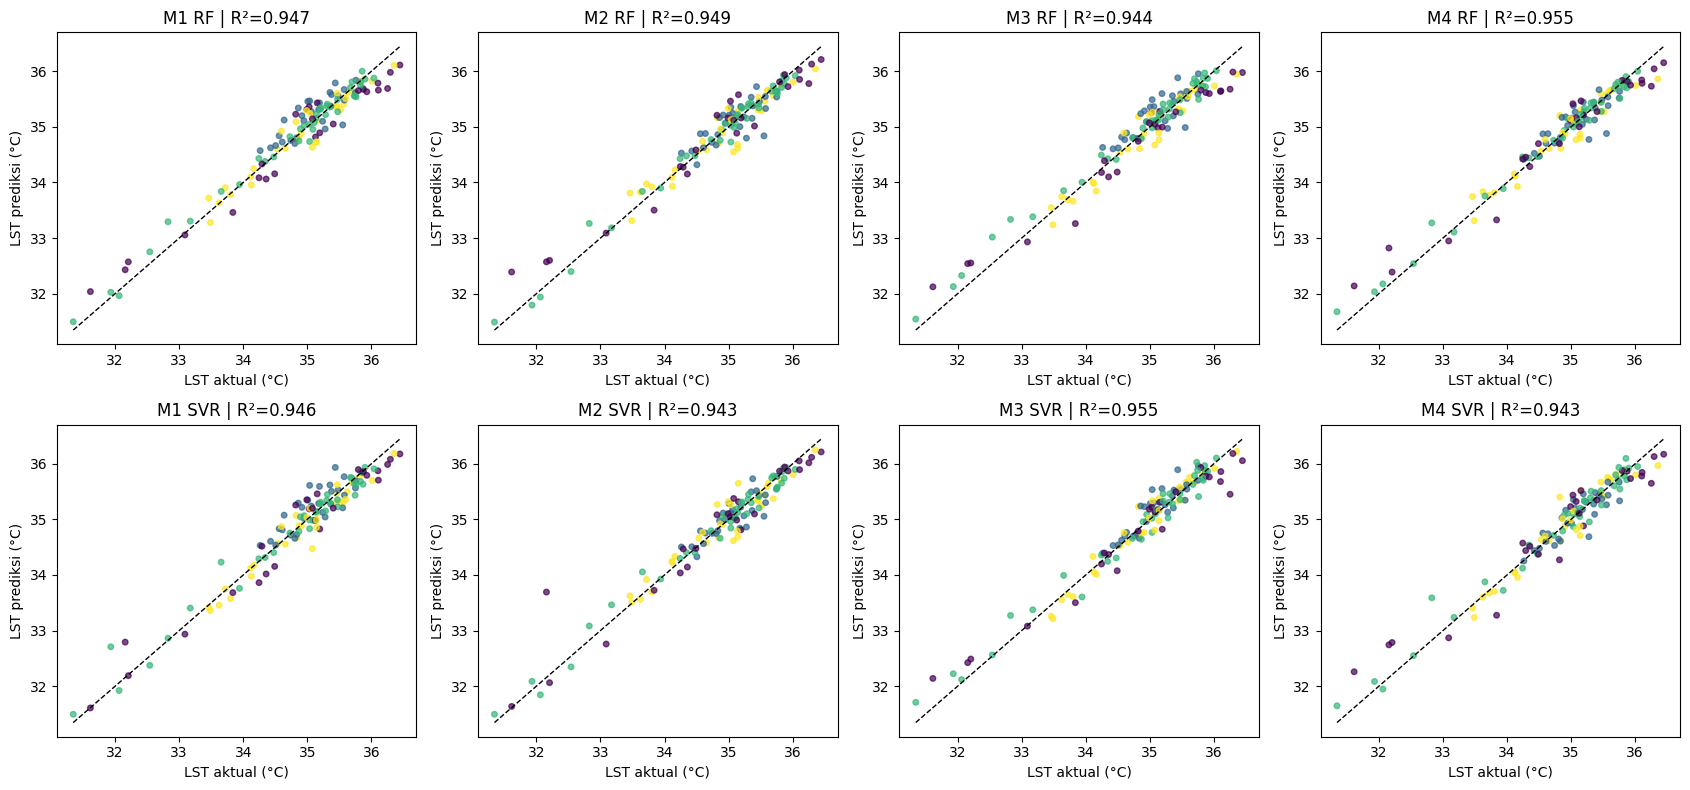

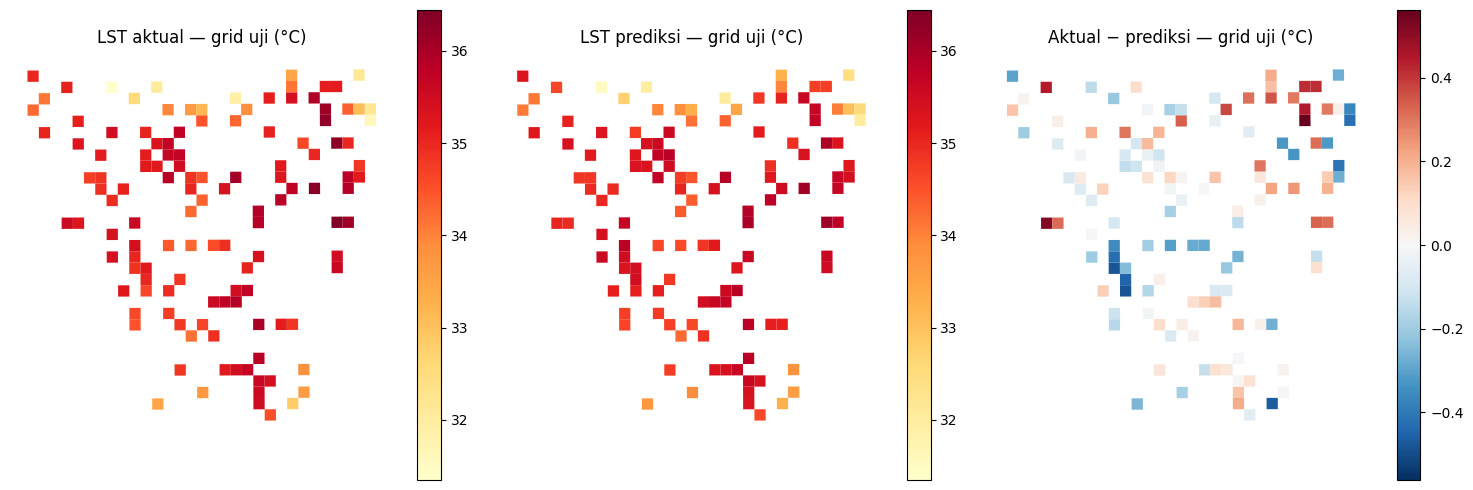

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for row, algorithm in enumerate(['RF', 'SVR']):
    for col, key in enumerate(MODEL_CONFIGS):
        result = all_results[(key, algorithm)]
        y = df.iloc[test_indices][TARGET_COL].to_numpy()
        prediction = result['test_prediction']
        ax = axes[row, col]
        ax.scatter(y, prediction, c=df.iloc[test_indices][CLUSTER_COL], cmap='viridis', s=16, alpha=.7)
        low, high = min(y.min(), prediction.min()), max(y.max(), prediction.max())
        ax.plot([low, high], [low, high], 'k--', lw=1)
        ax.set(title=f'{key[:2]} {algorithm} | R²={result["metrics"]["Test_R2"]:.3f}',
               xlabel='LST aktual (°C)', ylabel='LST prediksi (°C)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'prediksi_vs_aktual_holdout.png', dpi=160)
plt.show()
plt.close(fig)

map_test = spatial_predictions[spatial_predictions['split'].eq('test')]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
low = min(map_test[TARGET_COL].min(), map_test['predicted'].min())
high = max(map_test[TARGET_COL].max(), map_test['predicted'].max())
for ax, column, title in zip(axes, [TARGET_COL, 'predicted', 'residual'], ['LST aktual', 'LST prediksi', 'Aktual − prediksi']):
    opts = dict(cmap='RdBu_r') if column == 'residual' else dict(cmap='YlOrRd', vmin=low, vmax=high)
    if column == 'residual':
        limit = max(float(map_test['residual'].abs().max()), 1e-6)
        opts.update(vmin=-limit, vmax=limit)
    map_test.plot(column=column, ax=ax, legend=True, **opts)
    ax.set_title(title + ' — grid uji (°C)')
    ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'peta_residual_holdout.png', dpi=160)
plt.show()
plt.close(fig)

importance_rows = []
for key, config in MODEL_CONFIGS.items():
    result = all_results[(key, 'RF')]
    labels = df.iloc[train_indices][CLUSTER_COL].to_numpy()
    weights = [np.sum(labels == label) if label != 'global' else len(train_indices) for label in result['models']]
    importances = np.average([model.feature_importances_ for model in result['models'].values()], axis=0, weights=weights)
    importance_rows.extend(dict(ConfigKey=key, feature=feature, importance=float(value))
                           for feature, value in zip(config['features'], importances))
pd.DataFrame(importance_rows).to_csv(OUTPUT_DIR / 'feature_importance_rf.csv', index=False)


## 8. SHAP RF per fitur dan Shapley berkelompok per variabel

Untuk M2/M4, setiap grid dijelaskan dengan model klasternya sendiri. Background
diambil hanya dari data latih model tersebut. Kontribusi per fitur dihitung dengan
TreeExplainer interventional. Kontribusi kelompok LST/NDVI/NDBI dihitung terpisah
dengan enumerasi semua koalisi (maksimal 2³), menggunakan rata-rata prediksi atas
background empiris. Semua periode satu variabel diganti bersama dalam satu koalisi.
Ini berbeda dari sekadar menjumlahkan SHAP per lag. Enumerasi koalisi bersifat
eksak terhadap background yang disubsampel, bukan terhadap seluruh populasi.

Kedua dekomposisi diperiksa: baseline + jumlah kontribusi harus sama dengan prediksi.
Interpretasi bersifat asosiasi model; penggantian fitur interventional tidak
mempertahankan seluruh korelasi antarvariabel. Persentase kontribusi menggunakan
rata-rata nilai absolut, bukan persentase sebab-akibat suhu.


In [17]:
def variable_groups(features):
    return {variable: [i for i, name in enumerate(features) if name.lower().startswith(variable.lower())]
            for variable in ['LST', 'NDVI', 'NDBI']
            if any(name.lower().startswith(variable.lower()) for name in features)}


def exact_group_shap(predict, X, background, groups):
    X, background = np.asarray(X, dtype=float), np.asarray(background, dtype=float)
    if X.ndim != 2 or background.ndim != 2 or X.shape[1] != background.shape[1] or not len(background):
        raise ValueError('Bentuk X/background tidak cocok atau background kosong.')
    members = list(groups.values())
    flattened = [i for member in members for i in member]
    if sorted(flattened) != list(range(X.shape[1])):
        raise ValueError('Setiap fitur harus masuk tepat satu kelompok.')
    J, n, b = len(members), len(X), len(background)
    values = {}
    for coalition in range(1 << J):
        hybrid = np.broadcast_to(background, (n, b, X.shape[1])).copy()
        for j, indices in enumerate(members):
            if coalition & (1 << j):
                hybrid[:, :, indices] = X[:, None, indices]
        values[coalition] = np.asarray(predict(hybrid.reshape(n*b, X.shape[1]))).reshape(n, b).mean(axis=1)
    phi = np.zeros((n, J))
    for j in range(J):
        for coalition in range(1 << J):
            if coalition & (1 << j):
                continue
            size = coalition.bit_count()
            weight = math.factorial(size)*math.factorial(J-size-1)/math.factorial(J)
            phi[:, j] += weight*(values[coalition | (1 << j)]-values[coalition])
    predicted = np.asarray(predict(X))
    np.testing.assert_allclose(values[0]+phi.sum(axis=1), predicted, atol=1e-6, rtol=1e-6)
    return phi, values[0], predicted


def group_summary(phi, names, cluster=None):
    magnitudes = np.abs(phi)
    means = magnitudes.mean(axis=0)
    total = means.sum()
    rows = []
    for j, variable in enumerate(names):
        x = magnitudes[:, j]
        row = dict(variable=variable, vector_shap_mean=float(means[j]),
                   vector_shap_std=float(x.std()), vector_shap_sem=float(x.std()/np.sqrt(len(x))),
                   vector_shap_q25=float(np.quantile(x, .25)), vector_shap_q75=float(np.quantile(x, .75)),
                   vector_shap_median=float(np.median(x)),
                   vector_shap_pct=float(means[j]/total*100) if total else 0., n_samples=len(x))
        if cluster is not None:
            row['cluster'] = int(cluster)
        rows.append(row)
    return rows


c:\Users\Solideo G. Bangun\anaconda3\envs\env_baru\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP RF: M1_LagLST


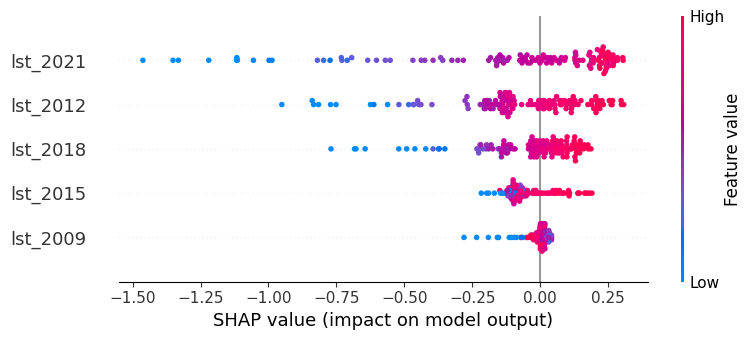

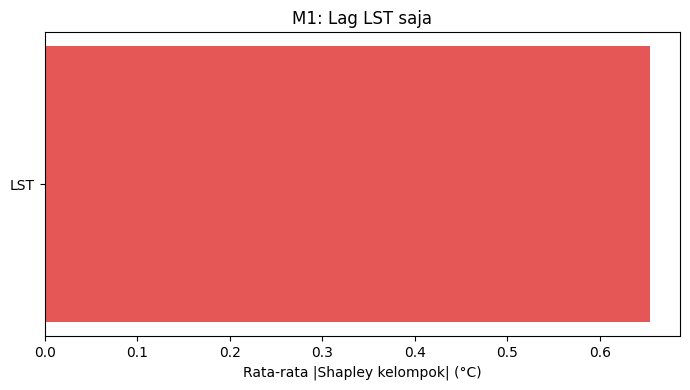

SHAP RF: M2_LagLST_byCluster


AssertionError: 
Not equal to tolerance rtol=1e-05, atol=0.0001

Mismatched elements: 1 / 126 (0.794%)
Max absolute difference: 0.00134234
Max relative difference: 3.80866224e-05
 x: array([34.57404 , 33.809431, 35.289197, 33.263845, 33.973394, 35.460721,
       33.826414, 35.661869, 35.342924, 34.704163, 35.003401, 35.303205,
       35.563651, 33.923035, 35.745201, 34.222868, 34.893054, 34.319378,...
 y: array([34.57404 , 33.809432, 35.289197, 33.263845, 33.973394, 35.460721,
       33.826414, 35.661869, 35.342925, 34.704163, 35.003402, 35.303205,
       35.563652, 33.923036, 35.745201, 34.222868, 34.893054, 34.319378,...

In [18]:
shap_summary_rows, shap_verification_rows = [], []
shap_store = {}
if RUN_SHAP:
    import shap
    rng = np.random.default_rng(SEED)
    for key, config in MODEL_CONFIGS.items():
        print('SHAP RF:', key, flush=True)
        result = all_results[(key, 'RF')]
        features = config['features']
        groups = variable_groups(features)
        names = list(groups)
        X_test = df.iloc[test_indices][features].to_numpy()
        labels_test = df.iloc[test_indices][CLUSTER_COL].to_numpy()
        labels_train = df.iloc[train_indices][CLUSTER_COL].to_numpy()
        sv = np.zeros_like(X_test)
        grouped = np.zeros((len(test_indices), len(groups)))
        base_tree = np.zeros(len(test_indices))
        base_group = np.zeros(len(test_indices))
        per_cluster_summary = []
        for cluster, model in result['models'].items():
            mask_test = labels_test == cluster if cluster != 'global' else np.ones(len(test_indices), dtype=bool)
            mask_train = labels_train == cluster if cluster != 'global' else np.ones(len(train_indices), dtype=bool)
            X_train = df.iloc[train_indices[mask_train]][features].to_numpy()
            background_indices = rng.choice(len(X_train), min(SHAP_BACKGROUND_SIZE, len(X_train)), replace=False)
            background = X_train[background_indices]
            explain = X_test[mask_test]
            explainer = shap.TreeExplainer(model, data=background, feature_perturbation='interventional')
            values = np.asarray(explainer.shap_values(explain, check_additivity=True))
            sv[mask_test] = values
            base_tree[mask_test] = float(np.asarray(explainer.expected_value).reshape(-1)[0])
            phi, base, predicted = exact_group_shap(model.predict, explain, background, groups)
            grouped[mask_test], base_group[mask_test] = phi, base
            if cluster != 'global':
                per_cluster_summary.extend(group_summary(phi, names, cluster))
            # Simpan identitas background untuk reproduksi interpretasi.
            bg_ids = df.iloc[train_indices[mask_train][background_indices]][['grid_id']]
            bg_ids.to_csv(OUTPUT_DIR / f'shap_background_{key}_{cluster}.csv', index=False)
        prediction = result['test_prediction']
        np.testing.assert_allclose(base_tree+sv.sum(axis=1), prediction, atol=1e-4, rtol=1e-5)
        np.testing.assert_allclose(base_group+grouped.sum(axis=1), prediction, atol=1e-6, rtol=1e-6)
        shap_verification_rows.append(dict(ConfigKey=key,
            feature_max_error=float(np.max(np.abs(base_tree+sv.sum(axis=1)-prediction))),
            group_max_error=float(np.max(np.abs(base_group+grouped.sum(axis=1)-prediction)))))
        shap_store[key] = dict(values=sv, grouped=grouped, baseline=base_tree, group_baseline=base_group,
                               features=features, groups=names, X=X_test)
        feature_export = df.iloc[test_indices][['grid_id', CLUSTER_COL]].reset_index(drop=True).copy()
        for i, feature in enumerate(features):
            feature_export[f'shap_{feature}'] = sv[:, i]
        feature_export['baseline'] = base_tree
        feature_export['prediction'] = prediction
        feature_export.to_csv(OUTPUT_DIR / f'shap_per_grid_{key}.csv', index=False)
        group_export = df.iloc[test_indices][['grid_id', CLUSTER_COL]].reset_index(drop=True).copy()
        for j, name in enumerate(names):
            group_export[f'shap_{name}'] = grouped[:, j]
        group_export['baseline'] = base_group
        group_export['prediction'] = prediction
        group_export.to_csv(OUTPUT_DIR / f'group_shap_per_grid_{key}.csv', index=False)
        if per_cluster_summary:
            pd.DataFrame(per_cluster_summary).to_csv(OUTPUT_DIR / f'true_vector_shap_cluster_{key}.csv', index=False)
        summaries = group_summary(grouped, names)
        for entry in summaries:
            variable = entry['variable']
            indices = groups[variable]
            mean_abs_feature = np.abs(sv[:, indices]).mean(axis=0)
            strongest = features[indices[int(mean_abs_feature.argmax())]]
            import re
            shap_summary_rows.append({'Model': config['label'], 'Variabel': variable,
                'Jumlah Lag': len(indices), 'Vector SHAP (mean)': entry['vector_shap_mean'],
                'Vector SHAP (std)': entry['vector_shap_std'], 'Kontribusi (%)': entry['vector_shap_pct'],
                'Lag Terkuat': int(re.search(r'(\d{4})', strongest).group(1)),
                'SHAP Lag Terkuat': float(mean_abs_feature.max())})
        plt.figure(figsize=(9, max(4, len(features)*.3)))
        shap.summary_plot(sv, X_test, feature_names=features, show=False, max_display=len(features))
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f'shap_summary_rf_{key}.png', dpi=160, bbox_inches='tight')
        plt.show()
        plt.close('all')
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.barh(names, [entry['vector_shap_mean'] for entry in summaries], color=['#e45756', '#54a24b', '#4c78a8'][:len(names)])
        ax.set(xlabel='Rata-rata |Shapley kelompok| (°C)', title=config['label'])
        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / f'true_vector_shap_overall_{key}.png', dpi=160)
        plt.show()
        plt.close(fig)
    pd.DataFrame(shap_summary_rows).to_csv(OUTPUT_DIR / 'tabel_vector_shap_summary.csv', index=False)
    pd.DataFrame(shap_verification_rows).to_csv(OUTPUT_DIR / 'shap_local_accuracy.csv', index=False)
    manifest['versions']['shap'] = shap.__version__
    manifest['shap_background_size_max'] = SHAP_BACKGROUND_SIZE
    (OUTPUT_DIR / 'run_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
    display(pd.DataFrame(shap_summary_rows).round(5))
    display(pd.DataFrame(shap_verification_rows))
else:
    print('SHAP tidak dijalankan: RUN_SHAP=False.')


## Hasil dan batas interpretasi

- `summary_evaluation.csv`: M1–M4 × RF/SVR, holdout dan CV data latih.
- `all_predictions_test_set.csv`: delapan prediksi pada grid uji yang sama.
- `standardisasi_svr_data_latih.csv`: mean, skala, dan varians tiap fitur/tahun,
  termasuk **NDVI/NDBI 2024**, per model/klaster.
- `audit_kualitas_periode.csv`, `audit_grid_inclusion.csv`, `split_membership.csv`:
  jejak kualitas dan cakupan sampel. Jangan mengartikan grid keluar sebagai nilai nol.
- `sensitivity_raw_vs_adjusted.csv`: pengaruh pilihan penyesuaian sensor pada model.
- `tabel_vector_shap_summary.csv`, `true_vector_shap_cluster_*.csv`, `shap_per_grid_*.csv`:
  interpretasi RF dan pemeriksaan local accuracy.
- `model_*.joblib`, `run_manifest.json`: model, konfigurasi, versi pustaka, dan hash input.

Ekspor ini tidak otomatis mengganti data dashboard. Output evaluasi notebook lama
tidak dipertahankan agar tidak tertukar dengan hasil perhitungan baru. Versi notebook
asli, termasuk visualisasi terdahulu, ada di file `*.sebelum_perbaikan.ipynb`.

Ketersediaan scene telah diperiksa melalui katalog publik, tetapi kelengkapan
**piksel setelah masking** ditentukan oleh ekspor audit Earth Engine. Penyesuaian
literatur masih memerlukan validasi lokal sebelum tren diinterpretasikan sebagai
perubahan fisik yang bebas pengaruh sensor. Skor model tidak menggantikan validasi itu.
